## With trained encoder and decoder, generate synthetic spectra from the latent space

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
# import pickle
import seaborn as sns
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Load saved encoder and decoder models

In [12]:
# Comprehensive model loading with fallback options
latent_dim = 16
MODEL_DIR = "/Users/aayushsaxena/Desktop/Oxford/scripts/learnspec/models/"

# Initialize variables
encoder = None
decoder = None
wavelength = None

print("Attempting to load models using multiple methods...")

# Method 1: Load from weights (most reliable for custom functions)
try:
    import sys
    sys.path.append('/Users/aayushsaxena/Desktop/Oxford/scripts/learnspec')
    from learnspec.src import load as loading, train as training
    
    print("Loading data to get dimensions...")
    # Load data to get dimensions and wavelength grid
    original_data, wavelength, redshifts, speclist = loading.load_data(
        data_dir="/Users/aayushsaxena/Desktop/Oxford/scripts/learnspec/data/", 
        data_path="dja_v4.2_z4-20/dja_v4.2_resampled_spectra_z4-20.npy", 
        wavelength_path="dja_v4.2_z4-20/dja_v4.2_resampled_wavelength_z4-20.npy", 
        redshift_path="dja_v4.2_z4-20/dja_v4.2_redshift_info_z4-20.npy", 
        speclist_path="dja_v4.2_z4-20/dja_v4.2_source_id_info_z4-20.npy")
    
    ### Scale the data
    resampled_data = loading.process_data(original_data, wavelength, scaler=True, scale_factor=1.0)
    print("Data shape after scaling: ", resampled_data.shape)

    input_dim = original_data.shape[1]
    print(f"Input dimension: {input_dim}")
    
    # Recreate VAE and load weights
    print("Recreating VAE model...")
    vae_model = training.create_vae_model(input_dim, latent_dim)
    WEIGHTS_PATH = os.path.join(MODEL_DIR, f"dja_z4_16_res3_dim{latent_dim}_vae_model.weights.h5")
    
    if os.path.exists(WEIGHTS_PATH):
        print("Loading weights...")
        vae_model.build(input_shape=(None, input_dim))
        vae_model.load_weights(WEIGHTS_PATH)
        encoder = vae_model.encoder
        decoder = vae_model.decoder
        print("✓ Method 1 successful: Loaded from weights")
    else:
        raise FileNotFoundError(f"Weights file not found: {WEIGHTS_PATH}")
        
except Exception as e:
    print(f"✗ Method 1 failed: {e}")
    
    # Method 2: Try to define custom objects and load
    try:
        print("Trying with custom sampling function...")
        
        # Define the sampling function that's missing
        def sampling(args):
            z_mean, z_log_var = args
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.random.normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon
        
        # Custom objects for loading
        custom_objects = {'sampling': sampling}
        
        ENCODER_PATH = os.path.join(MODEL_DIR, f"dja_z4_16_res3_dim{latent_dim}_vae_encoder.keras")
        DECODER_PATH = os.path.join(MODEL_DIR, f"dja_z4_16_res3_dim{latent_dim}_vae_decoder.keras")
        
        encoder = tf.keras.models.load_model(ENCODER_PATH, custom_objects=custom_objects, compile=False)
        decoder = tf.keras.models.load_model(DECODER_PATH, custom_objects=custom_objects, compile=False)
        print("✓ Method 2 successful: Loaded with custom objects")
        
    except Exception as e2:
        print(f"✗ Method 2 failed: {e2}")
        
        # Method 3: Manual architecture recreation (if you have the architecture details)
        try:
            print("Trying manual architecture recreation...")
            # This would require manually defining the encoder/decoder architecture
            # For now, let's skip this and suggest a workaround
            raise Exception("Manual recreation not implemented")
            
        except Exception as e3:
            print(f"✗ All methods failed. Last error: {e3}")

# Check if loading was successful
if encoder is not None and decoder is not None:
    print("\n🎉 Models loaded successfully!")
    print(f"Encoder input shape: {encoder.input.shape}")
    print(f"Decoder input shape: {decoder.input.shape}")  
    print(f"Decoder output shape: {decoder.output.shape}")
    if wavelength is not None:
        print(f"Wavelength grid: {len(wavelength)} points from {wavelength.min():.1f} to {wavelength.max():.1f} Å")
        
    # Test the models with a simple forward pass
    print("\nTesting models...")
    try:
        # Test encoder
        test_input = np.random.normal(0, 1, (1, encoder.input.shape[1]))
        z_mean, z_log_var, z = encoder.predict(test_input, verbose=0)
        print(f"✓ Encoder test passed - latent shape: {z.shape}")
        
        # Test decoder  
        test_latent = np.random.normal(0, 1, (1, decoder.input.shape[1]))
        reconstructed = decoder.predict(test_latent, verbose=0)
        print(f"✓ Decoder test passed - output shape: {reconstructed.shape}")
        
    except Exception as test_error:
        print(f"⚠️ Model test failed: {test_error}")
        
else:
    print("\n❌ Failed to load models.")
    print("\n🔧 Troubleshooting suggestions:")
    print("1. Check if weights file exists:")
    weights_path = os.path.join(MODEL_DIR, f"dja_z4_16_res3_dim{latent_dim}_vae_model.weights.h5")
    print(f"   {weights_path}")
    print(f"   Exists: {os.path.exists(weights_path)}")
    
    print("\n2. Try re-saving the models in your training notebook with:")
    print("   vae_model.encoder.save_weights('encoder_weights.h5')")
    print("   vae_model.decoder.save_weights('decoder_weights.h5')")
    
    print("\n3. Or copy the encoder/decoder creation code directly to this notebook")

Attempting to load models using multiple methods...
Loading data to get dimensions...
Transformed data saved to ../data/output/processed_spectra.npy
Data shape after scaling:  (2734, 3843)
Input dimension: 3843
Recreating VAE model...
✗ Method 1 failed: module 'learnspec.src.train' has no attribute 'create_vae_model'
Trying with custom sampling function...
✓ Method 2 successful: Loaded with custom objects

🎉 Models loaded successfully!
Encoder input shape: (None, 3843)
Decoder input shape: (None, 16)
Decoder output shape: (None, 3843)
Wavelength grid: 3843 points from 1120.9 to 8804.9 Å

Testing models...
✓ Encoder test passed - latent shape: (1, 16)
✓ Decoder test passed - output shape: (1, 3843)


## Reconstruct VAE from saved components

In [13]:
# Import the VAE class from your module
import sys
sys.path.append('/Users/aayushsaxena/Desktop/Oxford/scripts/learnspec/src')
from vae import VAE, sampling

# Reconstruct the VAE model
vae_model = VAE(encoder, decoder)

# Compile the VAE (optional, mainly for consistency)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
vae_model.compile(optimizer=optimizer)

print("✓ Successfully reconstructed VAE model")

# Get model dimensions
latent_dim = encoder.output[0].shape[-1]  # z_mean output shape
input_dim = decoder.output.shape[-1]

print(f"Input dimension: {input_dim}")
print(f"Latent dimension: {latent_dim}")

✓ Successfully reconstructed VAE model
Input dimension: 3843
Latent dimension: 16


In [14]:
### Extract the latent space representation
from learnspec.src import predict as prediction
z_mean, z_log_var, z = prediction.evaluate_latent_space(vae_model.encoder, resampled_data)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


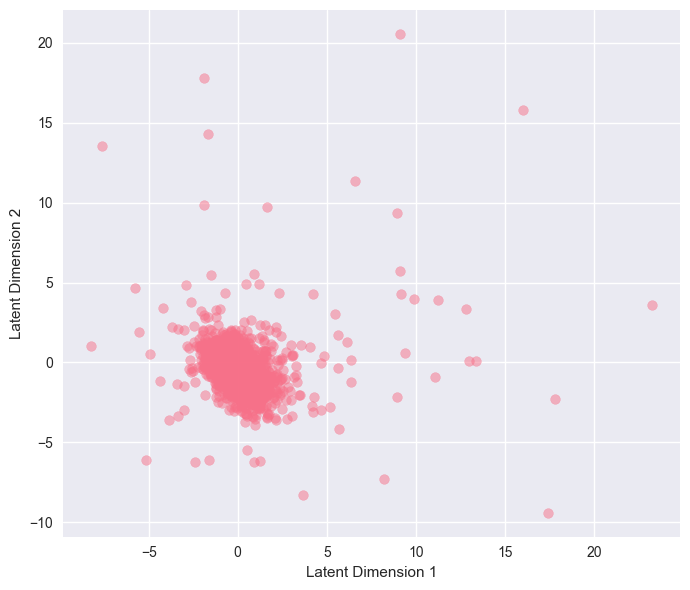

In [15]:
### Visualize the latent space
plt.close()
plt.figure(figsize=(7, 6))
plt.scatter(z_mean[:, 0], z_mean[:, 1], alpha=0.5)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
# plt.title("Latent Space Representation")
plt.tight_layout()
plt.show()

### Generate random spectra

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


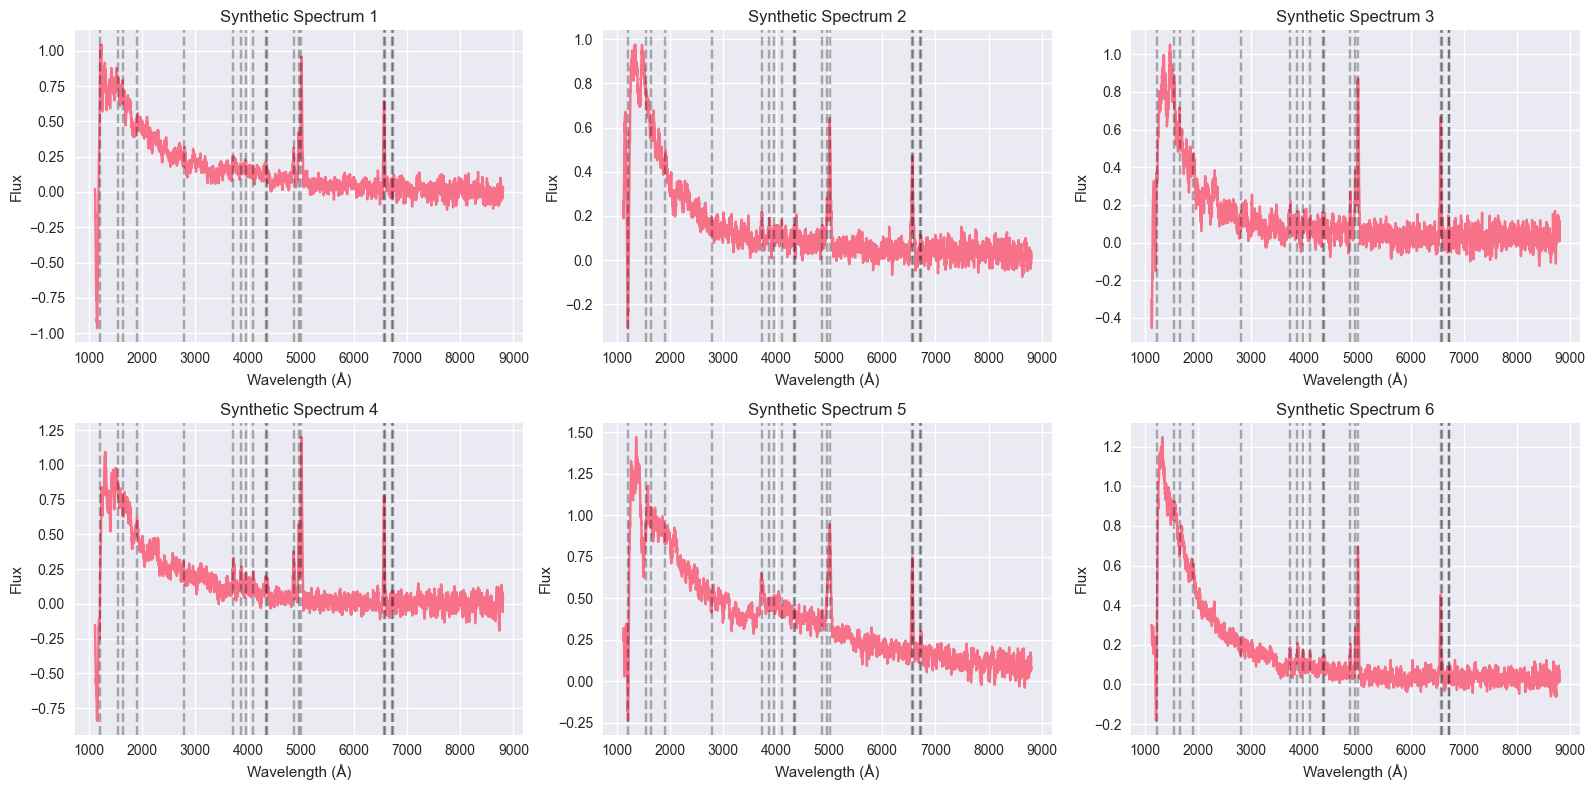

In [10]:
# Generate random synthetic spectra
from generate import generate_random_synthetic_spectra
from show_emlines import show_lines as sl

n_synthetic = 20
synthetic_spectra, synthetic_latent = generate_random_synthetic_spectra(
    vae_model.decoder, n_samples=n_synthetic, latent_dim=latent_dim
)

# Plot a few examples
plt.close()
plt.figure(figsize=(16, 8))
for i in range(min(6, n_synthetic)): # show a minimum of 6 spectra
    plt.subplot(2, 3, i+1)
    plt.plot(wavelength, synthetic_spectra[i])
    ### Show emission lines on the synthetic spectra
    sl.show_restlines(sl.lines_lim, sl.names_lim,
                      min_wave=1000, max_wave=8000, ypos=2.5, xoffset=20, lnames=False)
    plt.title(f'Synthetic Spectrum {i+1}')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Flux')

plt.tight_layout()
plt.show()